In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True).frame

print("Shape:", housing.shape)

print("Missing Values:",housing.isna().sum().sum())

print("Duplicated Rows:",housing.duplicated().sum())

Shape: (20640, 9)
Missing Values: 0
Duplicated Rows: 0


In [2]:
from sklearn.datasets import fetch_california_housing
import numpy as np

housing = fetch_california_housing(as_frame=True).frame

rng = np.random.default_rng(0)

messy = housing.copy()

n = int(len(messy) * 0.05)

idx = rng.choice(messy.index,size=n,replace=False)

messy.loc[idx, "Population"] = np.nan

print(messy["Population"].isna().sum())

1032


In [3]:
from sklearn.datasets import fetch_california_housing
import numpy as np

housing = fetch_california_housing(as_frame=True).frame

rng = np.random.default_rng(0)

messy = housing.copy()

n = int(len(messy)* 0.05)

idx = rng.choice(messy.index,size=n,replace=False)

messy.loc[idx,"Population"] = np.nan

mean_drop = (messy["Population"].dropna().mean())

mean_fill = (messy["Population"].fillna(messy["Population"].median()).mean())

print(mean_drop)

print(mean_fill)

1423.9820991432068
1411.0329941860466


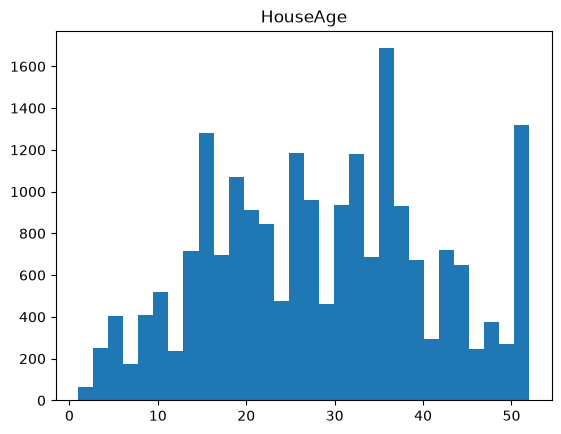

0.06167635658914729


In [4]:
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

housing = fetch_california_housing(as_frame=True).frame

fig, ax = plt.subplots()

ax.hist(housing["HouseAge"],bins=30)

ax.set_title("HouseAge")

plt.show()

cap_fraction = ((housing["HouseAge"] == 52).mean())

print(cap_fraction)

In [5]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True).frame

q1 = housing["AveRooms"].quantile(0.25)

q3 = housing["AveRooms"].quantile(0.75)

iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

count = (housing["AveRooms"] >upper_bound).sum()

print("Upper Bound:",upper_bound)

print("Outliers:",count)

Upper Bound: 8.469878027106942
Outliers: 466


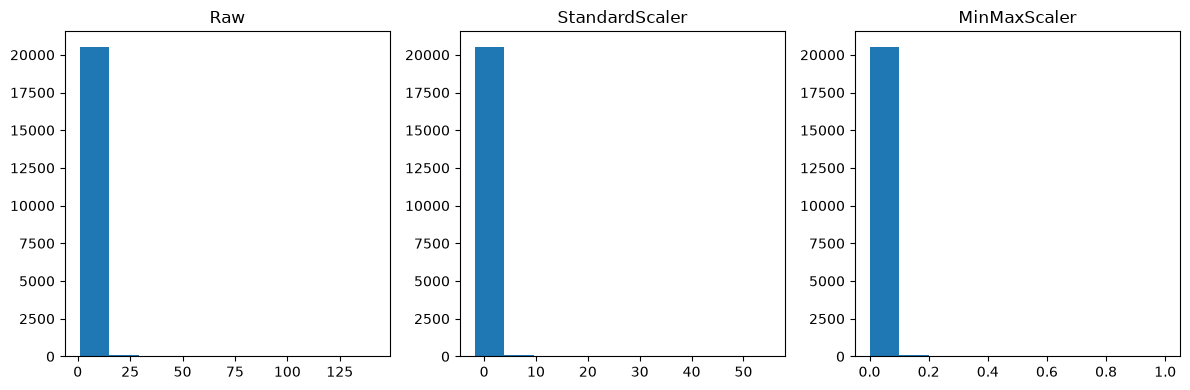

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (StandardScaler,MinMaxScaler)
import matplotlib.pyplot as plt

housing = fetch_california_housing(as_frame=True).frame

raw = housing[["AveRooms"]]

standard = StandardScaler().fit_transform(raw)

minmax = MinMaxScaler().fit_transform(raw)

fig, axes = plt.subplots(1,3,figsize=(12,4))

axes[0].hist(raw)
axes[0].set_title("Raw")
axes[1].hist(standard)
axes[1].set_title("StandardScaler")
axes[2].hist(minmax)
axes[2].set_title("MinMaxScaler")

plt.tight_layout()
plt.show()

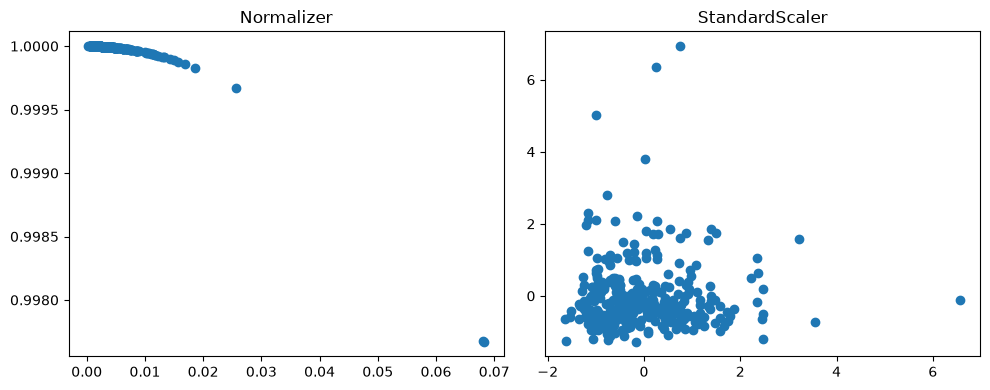

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (Normalizer,StandardScaler)
import matplotlib.pyplot as plt

housing = fetch_california_housing(as_frame=True).frame

sample = housing[["MedInc", "Population"]].sample(300,random_state=0)


normal_data = (Normalizer().fit_transform(sample))
standard_data = (StandardScaler().fit_transform(sample))

fig, axes = plt.subplots(1,2,figsize=(10,4))

axes[0].scatter(normal_data[:,0],normal_data[:,1])
axes[0].set_title("Normalizer")
axes[1].scatter(standard_data[:,0],standard_data[:,1])
axes[1].set_title("StandardScaler")

plt.tight_layout()
plt.show()